In [ ]:
MODEL_CLS = "dmlp"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\05_RS-DNCF


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from recsys import config, pipeline, trainer, evaluator, utils
import dncf

In [ ]:
PATH = f"./config/{DATASET}/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.builder.config_builder(PATH)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{cfg.dataset}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.pipeline,
)

dataloaders, interactions, histories = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    interactions=interactions,
    num_users=cfg.model.num_users,
    num_items=cfg.model.num_items,
    **cfg.model.params,
)

model = dncf.dmlp.Module(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.4997
	BEST EPOCH: 23


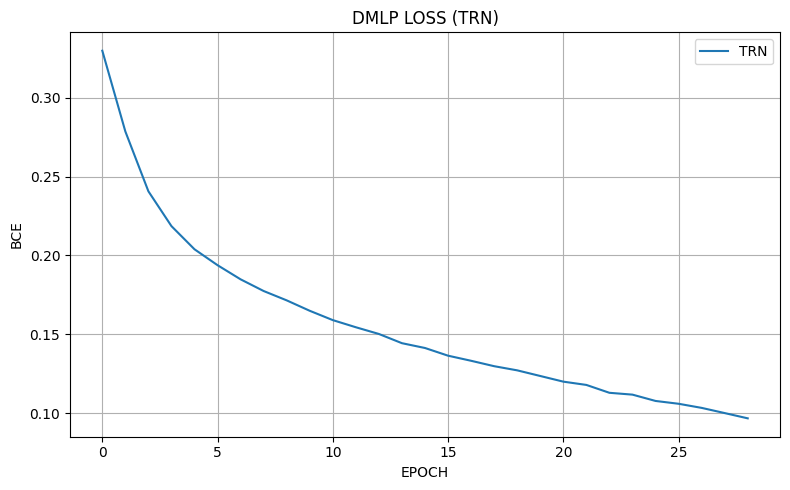

In [14]:
kwargs = dict(
    record=records["trn"],
    label="TRN",
    criterion="BCE",
    title="DMLP LOSS (TRN)",
)

utils.visualizer.main(**kwargs)

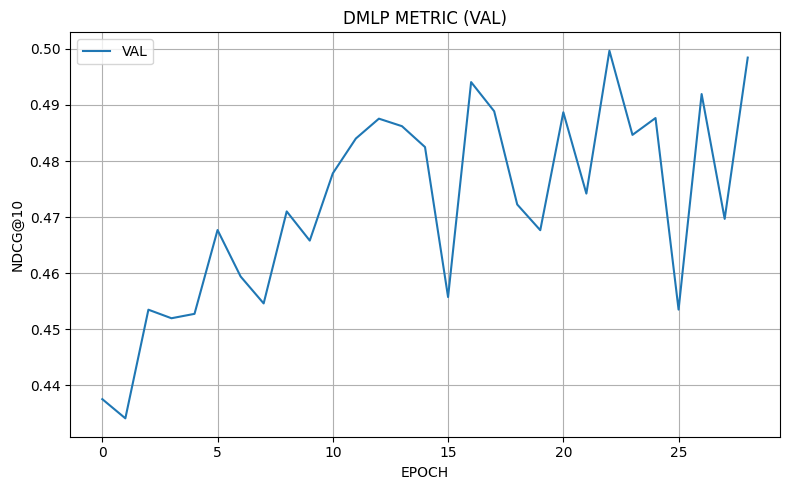

In [15]:
kwargs = dict(
    record=records["val"],
    label="VAL",
    criterion="NDCG@10",
    title="DMLP METRIC (VAL)",
)

utils.visualizer.main(**kwargs)

# Test

In [16]:
kwargs = dict(
    model=model,
    cfg=cfg.evaluator,
)

evaluator = evaluator.builder.evaluator_builder(**kwargs)

In [17]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3195/3195 [00:06<00:00, 523.18it/s]


In [18]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.870066,0.387171,0.345031,0.247450,0.469165
1,10,0.953947,0.298355,0.476625,0.298092,0.489085
2,15,0.975329,0.243750,0.542866,0.318993,0.501891
3,20,0.981908,0.210197,0.590022,0.331051,0.513423
4,25,0.985197,0.186974,0.631035,0.339580,0.524556
5,50,0.993421,0.122664,0.727105,0.357596,0.553826


# Save

In [19]:
PATH = f'./checkpoints/{cfg.dataset}/{cfg.model_cls}_{cfg.strategy}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)